# Import two tokenizers

In [ ]:
!pip install tiktoken
import tiktoken
gpt4_tokenizer = tiktoken.get_encoding('cl100k_base')

from transformers import BertTokenizer
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

# Attempting a direct translation from GPT4 to BERT and back

In [ ]:
# issue is that they have different tokenizers, so needs to be translated into text
starting_text = 'Hello, my name is Mike and I like purtpe.'

gpt4_tokens = gpt4_tokenizer.encode(starting_text)
bert_tokens = bert_tokenizer.encode(starting_text)

print(f'Starting text:\n{starting_text}')
print(f'\n\nGPT4 tokens:\n{gpt4_tokens}')
print(f'\nDecoded using GPT4:\n{gpt4_tokenizer.decode(gpt4_tokens)}')
print(f'\nDecoded using BERT:\n{bert_tokenizer.decode(gpt4_tokens)}')

Starting text:
Hello, my name is Mike and I like purtpe.


GPT4 tokens:
[9906, 11, 856, 836, 374, 11519, 323, 358, 1093, 4087, 83, 375, 13]

Decoded using GPT4:
Hello, my name is Mike and I like purtpe.

Decoded using BERT:
lately [unused10] [unused851] [unused831] [unused369] decent [unused318] [unused353] ¾ technical [unused82] [unused370] [unused12]


# The right way to translate (numbers to text)

In [ ]:
# text -> GPT4 tokens -> text -> BERT tokens

# to GPT4 tokens
starting_text = 'Hello, my name is Mike and I like purple.'
gpt4_tokens = gpt4_tokenizer.encode(starting_text)

# back to text
gpt4_recon_text = gpt4_tokenizer.decode(gpt4_tokens)

# then to bert tokens
bert_tokens = bert_tokenizer.encode(gpt4_recon_text)

# show the reconstruction
bert_tokenizer.decode(bert_tokens)

'[CLS] hello, my name is mike and i like purple. [SEP]'

# Translation functions

In [ ]:
!pip -q install tiktoken
import tiktoken
from transformers import BertTokenizer

gpt4_tokenizer = tiktoken.get_encoding('cl100k_base')
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [ ]:
text = "Ground control to Major Tom!"

bert_tokens = bert_tokenizer.encode(text)
gpt4_tokens = gpt4_tokenizer.encode(text)

print('bert_tokens:',bert_tokens)
print('gpt4_tokens:',gpt4_tokens)

bert_tokens: [101, 2598, 2491, 2000, 2350, 3419, 999, 102]
gpt4_tokens: [31814, 2585, 311, 17559, 8529, 0]


In [ ]:
def bert_2_gpt4(bert_tokens):
  bert_back_to_text = bert_tokenizer.decode(bert_tokens, skip_special_tokens = True)
  gpt4_tokens = gpt4_tokenizer.encode(bert_back_to_text)
  return bert_back_to_text, gpt4_tokens

def gpt4_2_bert(gpt4_tokens):
  gpt4_back_to_text = gpt4_tokenizer.decode(gpt4_tokens)
  bert_tokens = bert_tokenizer.encode(gpt4_back_to_text)
  return gpt4_back_to_text, bert_tokens

In [ ]:
bert_2_gpt4(bert_tokens)

('ground control to major tom!', [1993, 2585, 311, 3682, 10390, 0])

In [ ]:
gpt4_2_bert(gpt4_tokens)

('Ground control to Major Tom!', [101, 2598, 2491, 2000, 2350, 3419, 999, 102])

# BERT $\rightarrow$ GPT4 $\rightarrow$ BERT

In [10]:
original_text = "I wanted to paste in a thought-provoking quote ehre, but I didn\'t"
original_text

"I wanted to paste in a thought-provoking quote ehre, but I didn't"

In [11]:
bert_tokens = bert_tokenizer.encode(original_text)
bert_tokens

[101,
 1045,
 2359,
 2000,
 19351,
 1999,
 1037,
 2245,
 1011,
 4013,
 22776,
 14686,
 15501,
 2890,
 1010,
 2021,
 1045,
 2134,
 1005,
 1056,
 102]

In [14]:
bert_2_gpt4_text = bert_2_gpt4(bert_tokens)[0]
bert_2_gpt4_text

"i wanted to paste in a thought - provoking quote ehre, but i didn't"

In [15]:
back_to_bert = bert_tokenizer.encode(bert_2_gpt4_text)
back_to_bert

[101,
 1045,
 2359,
 2000,
 19351,
 1999,
 1037,
 2245,
 1011,
 4013,
 22776,
 14686,
 15501,
 2890,
 1010,
 2021,
 1045,
 2134,
 1005,
 1056,
 102]

#  GPT4 $\rightarrow$ BERT $\rightarrow$ GPT4


In [22]:
original_text = "I wanted to paste in a thought-provoking quote here, but I didn\'t"
original_text

"I wanted to paste in a thought-provoking quote here, but I didn't"

In [23]:
gpt4_tokens = gpt4_tokenizer.encode(original_text)
gpt4_tokens

[40,
 4934,
 311,
 25982,
 304,
 264,
 3463,
 10039,
 85,
 10979,
 12929,
 1618,
 11,
 719,
 358,
 3287,
 956]

In [24]:
gpt4_to_bert_text = gpt4_2_bert(gpt4_tokens)[0]
gpt4_to_bert_text

"I wanted to paste in a thought-provoking quote here, but I didn't"

In [25]:
back_to_gpt4 = gpt4_tokenizer.encode(gpt4_to_bert_text)
back_to_gpt4

[40,
 4934,
 311,
 25982,
 304,
 264,
 3463,
 10039,
 85,
 10979,
 12929,
 1618,
 11,
 719,
 358,
 3287,
 956]

# Books Experiment

In [9]:
import re
import requests
from urllib.parse import urlparse

import string

!pip install tiktoken
import tiktoken

In [10]:
tokenizer = tiktoken.get_encoding('cl100k_base')
tokenizer

<Encoding 'cl100k_base'>

## Boks

In [11]:
base_url = 'https://www.gutenberg.org/cache/epub/'
base_url

'https://www.gutenberg.org/cache/epub/'

In [12]:
book_urls = [
    ['84', 'Frankenstein'],
    ['64317', 'GreatGatsby'],
    ['11', 'AliceWonderland'],
    ['1513', 'RomeoJuliet'],
    ['76', 'HuckFinn'],
    ['219', 'HeartDarkness'],
    ['2591', 'GrimsTales'],
    ['2148', 'EdgarAllenPoe'],
    ['36', 'WarOfTheWorlds'],
    ['829', 'GulliversTravels']
]

In [13]:
print('    Book title    | Chars | Tokens | Compression')
print('-'*50)

for code, title in book_urls:
  # get the text
  full_url = base_url + code + '/pg' + code + '.txt'
  text = requests.get(full_url).text
  num_chars = len(text)

  # tokenize
  tokens = tokenizer.encode(text)
  num_tokens = len(tokens)

  # compression ratio
  compress = 100*num_tokens/num_chars

  print(f'{title:16} | {num_chars:>7,d} | {num_tokens:>7,d} | {compress:>3.2f}%')

    Book title    | Chars | Tokens | Compression
--------------------------------------------------
Frankenstein     | 446,544 | 102,419 | 22.94%
GreatGatsby      | 296,858 |  70,343 | 23.70%
AliceWonderland  | 167,674 |  41,457 | 24.72%
RomeoJuliet      | 167,429 |  43,761 | 26.14%
HuckFinn         | 602,714 | 159,125 | 26.40%
HeartDarkness    | 232,885 |  56,483 | 24.25%
GrimsTales       | 549,736 | 137,252 | 24.97%
EdgarAllenPoe    | 632,136 | 144,315 | 22.83%
WarOfTheWorlds   | 363,420 |  84,580 | 23.27%
GulliversTravels | 611,742 | 143,560 | 23.47%


## Websites

In [21]:
web_urls = [
    'http://python.org/',
    'https://pytorch.org/',
    'https://sudoku.com/',
    'https://reddit.com/',
    'https://visiteurope.com/en/',
    'https://sincxpress.com/',
    'https://openai.com/',
    'https://theuselessweb.com/',
    'https://maps.google.com/',
    'https://pigeonsarentreal.co.uk/'
]

In [22]:
col1 = 'Website'
col2 = 'Chars'
col3 = 'Tokens'
col4 = 'Compression'

width1 = 30
width2 = 10

print(f'{col1:>{width1}} | {col2:>{width2}} | {col3:>{width2}} | {col4:>{width2}}')
print('-' * (width1 + 3 * (width2 + 3)))

for url in web_urls:
    text = requests.get(url).text
    num_chars = len(text)

    tokens = tokenizer.encode(text)
    num_tokens = len(tokens)

    compress = 100 * num_tokens / num_chars if num_chars else 0.0
    title = url.split('/')[2]

    print(
        f'{title:>{width1}} | '
        f'{num_chars:>{width2},} | '
        f'{num_tokens:>{width2},} | '
        f'{compress:>{width2}.2f}%'
    )

                       Website |      Chars |     Tokens | Compression
---------------------------------------------------------------------
                    python.org |     47,951 |     12,171 |      25.38%
                   pytorch.org |    186,359 |     57,264 |      30.73%
                    sudoku.com |    140,801 |     51,352 |      36.47%
                    reddit.com |    190,240 |     90,253 |      47.44%
               visiteurope.com |    405,865 |    155,118 |      38.22%
                sincxpress.com |     25,580 |      6,843 |      26.75%
                    openai.com |     11,617 |      6,386 |      54.97%
             theuselessweb.com |      4,756 |      1,329 |      27.94%
               maps.google.com |    216,212 |    109,454 |      50.62%
        pigeonsarentreal.co.uk |      7,300 |      2,050 |      28.08%


## String Lib

In [25]:
import string

print(string.__dict__['__doc__'])

A collection of string constants.

Public module variables:

whitespace -- a string containing all ASCII whitespace
ascii_lowercase -- a string containing all ASCII lowercase letters
ascii_uppercase -- a string containing all ASCII uppercase letters
ascii_letters -- a string containing all ASCII letters
digits -- a string containing all ASCII decimal digits
hexdigits -- a string containing all ASCII hexadecimal digits
octdigits -- a string containing all ASCII octal digits
punctuation -- a string containing all ASCII punctuation characters
printable -- a string containing all ASCII characters considered printable




In [24]:
string.ascii_lowercase

'abcdefghijklmnopqrstuvwxyz'

In [29]:
string.whitespace

' \t\n\r\x0b\x0c'

In [26]:
tokenizer.encode(string.ascii_lowercase)

[68612]

In [28]:
col1 = 'Attribute'
col2 = 'Chars'
col3 = 'Tokens'
col4 = 'Compression'

width1 = 30
width2 = 10

print(f'{col1:>{width1}} | {col2:>{width2}} | {col3:>{width2}} | {col4:>{width2}}')
print('-' * (width1 + 3 * (width2 + 3)))

for k,v in string.__dict__.items():
  if isinstance(v, str) and (len(v)>0):
    # text = requests.get(url).text

    # get text
    num_chars = len(v)

    tokens = tokenizer.encode(v)
    num_tokens = len(tokens)

    compress = 100 * num_tokens / num_chars if num_chars else 0.0

    print(
        f'{k:>{width1}} | '
        f'{num_chars:>{width2},} | '
        f'{num_tokens:>{width2},} | '
        f'{compress:>{width2}.2f}%'
    )

                     Attribute |      Chars |     Tokens | Compression
---------------------------------------------------------------------
                      __name__ |          6 |          1 |      16.67%
                       __doc__ |        622 |        109 |      17.52%
                      __file__ |         29 |          8 |      27.59%
                    __cached__ |         54 |         17 |      31.48%
                    whitespace |          6 |          4 |      66.67%
               ascii_lowercase |         26 |          1 |       3.85%
               ascii_uppercase |         26 |          1 |       3.85%
                 ascii_letters |         52 |          2 |       3.85%
                        digits |         10 |          4 |      40.00%
                     hexdigits |         22 |          7 |      31.82%
                     octdigits |          8 |          3 |      37.50%
                   punctuation |         32 |         21 |      65.62%
       

# Tokenization in different languages

In [3]:
!pip install tiktoken
import tiktoken
gpt_tokenizer = tiktoken.get_encoding('cl100k_base')

from transformers import BertTokenizer
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [1]:
languages = ['English', 'Spanish', 'Arabic', 'Persian', 'Lithuanian', 'Chinese', 'Tamil', 'Esperanto']
sentences = [
    'Blue towels are great because they remind you of the sea, although the sea is wet and towels work better when they are dry.',
    'Las toallas azules son geniales porque te recuerdan al mar, aunque el mar está mojado y las toallas funcionan mejor cuando están secas.',
    'المناشف الزرقاء رائعة لأنها تذكرك بالبحر، رغم أن البحر مبلل والمناشف تعمل بشكل أفضل عندما تكون جافة.',
    'حوله‌های آبی عالی هستند چون تو را به یاد دریا می‌اندازند، اگرچه دریا خیس است و حوله‌ها وقتی خشک هستند بهتر کار می‌کنند.',
    'Mėlyni rankšluosčiai yra puikūs, nes jie primena jūrą, nors jūra yra šlapia, o rankšluosčiai geriau veikia, kai yra sausi.',
    '蓝色的毛巾很棒，因为它们让你想起大海，尽管大海是湿的，而毛巾在干燥时效果更好。',
    'நீல நிறத் துணிகள் அருமையானவை, ஏனெனில் அவை கடலை நினைவூட்டுகின்றன, ஆனால் கடல் ஈரமாக இருக்கும் மற்றும் துணிகள் உலர்ந்தபோது சிறப்பாக செயல்படுகின்றன.',
    'Bluaj mantukoj estas bonegaj ĉar ili memorigas vin pri la maro, kvankam la maro estas malseka kaj mantukoj funkcias pli bone kiam ili estas sekaj.'
]
sentences

['Blue towels are great because they remind you of the sea, although the sea is wet and towels work better when they are dry.',
 'Las toallas azules son geniales porque te recuerdan al mar, aunque el mar está mojado y las toallas funcionan mejor cuando están secas.',
 'المناشف الزرقاء رائعة لأنها تذكرك بالبحر، رغم أن البحر مبلل والمناشف تعمل بشكل أفضل عندما تكون جافة.',
 'حوله\u200cهای آبی عالی هستند چون تو را به یاد دریا می\u200cاندازند، اگرچه دریا خیس است و حوله\u200cها وقتی خشک هستند بهتر کار می\u200cکنند.',
 'Mėlyni rankšluosčiai yra puikūs, nes jie primena jūrą, nors jūra yra šlapia, o rankšluosčiai geriau veikia, kai yra sausi.',
 '蓝色的毛巾很棒，因为它们让你想起大海，尽管大海是湿的，而毛巾在干燥时效果更好。',
 'நீல நிறத் துணிகள் அருமையானவை, ஏனெனில் அவை கடலை நினைவூட்டுகின்றன, ஆனால் கடல் ஈரமாக இருக்கும் மற்றும் துணிகள் உலர்ந்தபோது சிறப்பாக செயல்படுகின்றன.',
 'Bluaj mantukoj estas bonegaj ĉar ili memorigas vin pri la maro, kvankam la maro estas malseka kaj mantukoj funkcias pli bone kiam ili estas sekaj.']

In [16]:
col1 = 'Language'
col2 = 'Chars'
col3 = 'Tokens'
col4 = 'BERT'
col5 = 'GPT'

width1 = 30
width2 = 10

print(f'{col1:>{width1}} | {col2:>{width2}} | {col3:>{width2}} | {col4:>{width2}} | {col5:>{width2}}')
print('-' * (width1 + 4 * (width2 + 3)))

for k, v in zip(languages, sentences):
    if isinstance(v, str) and len(v) > 0:
        num_chars = len(v)

        gpt_tokens = gpt_tokenizer.encode(v)
        gpt_num_tokens = len(gpt_tokens)
        gpt_compress = 100 * gpt_num_tokens / num_chars if num_chars else 0.0

        bert_tokens = bert_tokenizer.encode(v)
        bert_num_tokens = len(bert_tokens)
        bert_compress = 100 * bert_num_tokens / num_chars if num_chars else 0.0

        print(
            f'{k:>{width1}} | '
            f'{num_chars:>{width2},} | '
            f'{gpt_num_tokens:>{width2},} | '
            f'{bert_compress:>{width2}.2f} | '
            f'{gpt_compress:>{width2}.2f}'
        )


                      Language |      Chars |     Tokens |       BERT |        GPT
----------------------------------------------------------------------------------
                       English |        123 |         26 |      22.76 |      21.14
                       Spanish |        135 |         35 |      36.30 |      25.93
                        Arabic |        100 |         77 |      85.00 |      77.00
                       Persian |        119 |         87 |      78.99 |      73.11
                    Lithuanian |        122 |         62 |      43.44 |      50.82
                       Chinese |         39 |         55 |     105.13 |     141.03
                         Tamil |        144 |        202 |      19.44 |     140.28
                     Esperanto |        146 |         50 |      39.73 |      34.25


# Zipf's law

$$ frequency \propto \frac{1}{rank} $$

## Prereq

In [40]:
import tiktoken

tokenizer = tiktoken.get_encoding('cl100k_base')

In [41]:
import numpy as np

nums = np.array([1,1,3,2,2,2,9,9,9,-1,-1,-1,-1,-1,-1])
uniq, counts = np.unique(nums, return_counts = True)

for n, c in zip(uniq, counts):
  print(f'The number {n:2} apears {c} times.')

The number -1 apears 6 times.
The number  1 apears 2 times.
The number  2 apears 3 times.
The number  3 apears 1 times.
The number  9 apears 3 times.


In [42]:
text = 'Hello, my name is Adrian and I like to each chocolate.'
org_text = [l.lower() for l in text]

uniq, counts = np.unique(org_text, return_counts = True)
for n, c in zip(uniq, counts):
  print(f'The number {n:2} apears {c} times.')

The number    apears 10 times.
The number ,  apears 1 times.
The number .  apears 1 times.
The number a  apears 6 times.
The number c  apears 3 times.
The number d  apears 2 times.
The number e  apears 5 times.
The number h  apears 3 times.
The number i  apears 4 times.
The number k  apears 1 times.
The number l  apears 4 times.
The number m  apears 2 times.
The number n  apears 3 times.
The number o  apears 4 times.
The number r  apears 1 times.
The number s  apears 1 times.
The number t  apears 2 times.
The number y  apears 1 times.


## Book's Zipf's Law

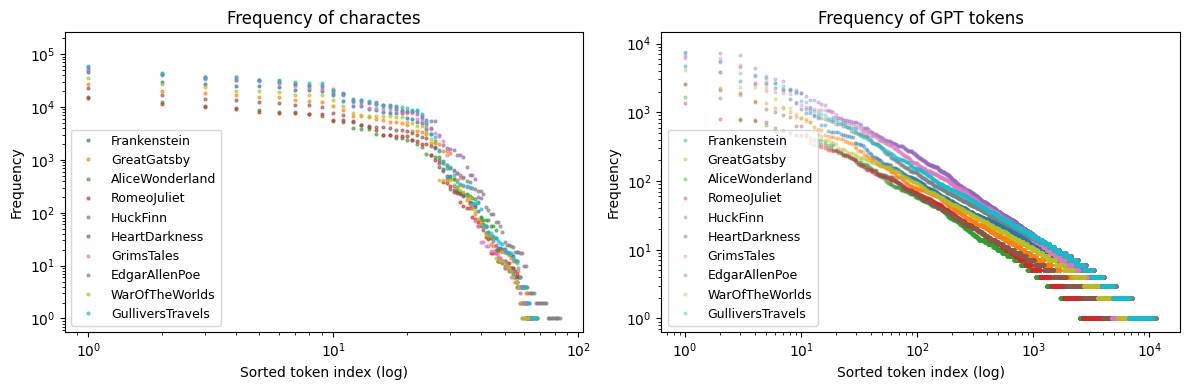

In [49]:
import requests
import matplotlib.pyplot as plt

base_url = 'https://www.gutenberg.org/cache/epub/'

book_urls = [
    ['84', 'Frankenstein'],
    ['64317', 'GreatGatsby'],
    ['11', 'AliceWonderland'],
    ['1513', 'RomeoJuliet'],
    ['76', 'HuckFinn'],
    ['219', 'HeartDarkness'],
    ['2591', 'GrimsTales'],
    ['2148', 'EdgarAllenPoe'],
    ['36', 'WarOfTheWorlds'],
    ['829', 'GulliversTravels']
]

_, axs = plt.subplots(1,2,figsize = (12,4))

for code, title in book_urls:
  # get the text
  full_url = base_url + code + '/pg' + code + '.txt'
  text = requests.get(full_url).text
  org_text = [l.lower() for l in text]

  uniletters, counts = np.unique(org_text, return_counts = True)

  axs[0].plot(np.sort(counts)[::-1], '.', markersize = 4, alpha = .6, label = title)

  # and for tokens
  tokens = tokenizer.encode(text)
  unitokens, counts = np.unique(tokens, return_counts = True)
  axs[1].plot(np.sort(counts)[::-1], '.', markersize = 4, alpha= .3, label = title)

# axis adjustements
for a in axs:
  a.legend(fontsize = 9)
  a.set(xscale = 'log', yscale = 'log', xlabel = 'Sorted token index (log)', ylabel = 'Frequency')

axs[0].set_title('Frequency of charactes')
axs[1].set_title('Frequency of GPT tokens')

plt.tight_layout()
plt.show()

# Word variations in Claude tokenizer

* Impact of spaces on tokenization
* How tokenizers deal with misspellings or spelling variations
* The effect of different punctuations on tokenizations
* How code looks when tokenized

In [75]:
from transformers import GPT2TokenizerFast

tokenizer = GPT2TokenizerFast.from_pretrained('Xenova/claude-tokenizer')

tokenizer_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Exploring the tokenizer

In [76]:
tokenizer.vocab_size

65000

In [77]:
tokenizer.encode('this is some text')

[3490, 365, 895, 1373]

In [78]:
tokenizer('this is some text', return_tensors = 'pt')

{'input_ids': tensor([[3490,  365,  895, 1373]]), 'attention_mask': tensor([[1, 1, 1, 1]])}

Some examples of multitoken words

In [80]:
words = [
    'hypothetical',
    ' hypothetical',
    'hypothetical ',
    ' hypothetical '
]

for word in words:
  toks = tokenizer.encode(word)
  print(f'"{word}" has {len(toks)} tokens ({toks}):\n  {[tokenizer.decode(t) for t in toks]}')

"hypothetical" has 2 tokens ([30678, 36881]):
  ['hypot', 'hetical']
" hypothetical" has 1 tokens ([44086]):
  [' hypothetical']
"hypothetical " has 3 tokens ([30678, 36881, 225]):
  ['hypot', 'hetical', ' ']
" hypothetical " has 2 tokens ([44086, 225]):
  [' hypothetical', ' ']


In [81]:
words = [' straight forward',
         ' straightforward',
         ' straight-forward']

for word in words:
  toks = tokenizer.encode(word)
  print(f'"{word}" has {len(toks)} tokens ({toks}):\n {[tokenizer.decode(t) for t in toks]}')

" straight forward" has 2 tokens ([7638, 4258]):
 [' straight', ' forward']
" straightforward" has 1 tokens ([29388]):
 [' straightforward']
" straight-forward" has 3 tokens ([7638, 17, 6978]):
 [' straight', '-', 'forward']


In [82]:
words = ['parttime',
         ' part-time',
         'part-time']

for word in words:
  toks = tokenizer.encode(word)
  print(f'"{word}" has {len(toks)} tokens ({toks}):\n {[tokenizer.decode(t) for t in toks]}')

"parttime" has 2 tokens ([1620, 793]):
 ['part', 'time']
" part-time" has 3 tokens ([919, 17, 793]):
 [' part', '-', 'time']
"part-time" has 3 tokens ([1620, 17, 793]):
 ['part', '-', 'time']


Common misspellings

In [83]:
words = [' accommodate acommodate',
         ' a lot alot',
         'occurrence occurence occurance']

for word in words:
  toks = tokenizer.encode(word)
  print(f'"{word}" has {len(toks)} tokens ({toks}):\n {[tokenizer.decode(t) for t in toks]}')

" accommodate acommodate" has 4 tokens ([27029, 1163, 17293, 353]):
 [' accommodate', ' ac', 'ommod', 'ate']
" a lot alot" has 4 tokens ([269, 3949, 460, 331]):
 [' a', ' lot', ' al', 'ot']
"occurrence occurence occurance" has 6 tokens ([48275, 2535, 540, 11970, 8265, 634]):
 ['occurrence', ' occ', 'ure', 'nce', ' occur', 'ance']


Punctuation

In [84]:
sentences = [
    'People say, you shouldn\'t do that.',
    'People say; you shouldn\'t do that.',
    'People say -- you shouldn\'t do that.'
]

for senten in sentences:
  toks = tokenizer.encode(senten)
  print(f'"{senten}" has {len(toks)} tokens ({toks}):\n {[tokenizer.decode(t) for t in toks]}')

"People say, you shouldn't do that." has 9 tokens ([9308, 2236, 16, 583, 12329, 828, 705, 427, 18]):
 ['People', ' say', ',', ' you', ' shouldn', "'t", ' do', ' that', '.']
"People say; you shouldn't do that." has 9 tokens ([9308, 2236, 31, 583, 12329, 828, 705, 427, 18]):
 ['People', ' say', ';', ' you', ' shouldn', "'t", ' do', ' that', '.']
"People say -- you shouldn't do that." has 9 tokens ([9308, 2236, 1786, 583, 12329, 828, 705, 427, 18]):
 ['People', ' say', ' --', ' you', ' shouldn', "'t", ' do', ' that', '.']
